# Quebec Winter Tire Fulfillment Gap — Analysis

Investigating JF Bélanger's (VP Sales, Quebec) question about lost customers ahead of winter tire season.

**Scenario:** Sales reps in Quebec report losing garage customers ahead of winter tire season, claiming orders couldn't be fulfilled in time. This notebook works through confirming whether that's true, benchmarking it against other regions, ruling out simpler explanations, quantifying the business impact, and tracing it to a root cause

### Importing the sqlite database

In [ ]:
import sqlite3
import pandas as pd

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)

DB_PATH = 'touchette.db'
conn = sqlite3.connect(DB_PATH)

def q(sql, params=None):
    """Run a SQL query against the Touchette DB and return a DataFrame."""
    return pd.read_sql_query(sql, conn, params=params)

print('Connected. Tables available:')
print(q("SELECT name FROM sqlite_master WHERE type='table'"))

Connected. Tables available:
                  name
0           warehouses
1             products
2           sales_reps
3            customers
4  inventory_snapshots
5               orders
6          order_items


## Quick schema peek

In [4]:
for t in ['warehouses','products','sales_reps','customers','orders','order_items','inventory_snapshots']:
    print(f'--- {t} ---')
    display(q(f'SELECT * FROM {t} LIMIT 3'))

--- warehouses ---


,warehouse_id,name,city,province
0,1,GT Vancouver DC,Vancouver,BC
1,2,GT Calgary DC,Calgary,AB
2,3,GT Toronto DC,Toronto,ON


--- products ---


,product_id,sku,brand,model,tire_type,size,cost,list_price
0,1,SKU-0001,Michelin,Michelin WeatherGrip2,Winter,245/40R19,68.92,108.37
1,2,SKU-0002,Michelin,Michelin Defender5,Winter,215/60R16,147.06,228.39
2,3,SKU-0003,Michelin,Michelin WeatherGrip5,Summer,235/55R18,58.97,81.27


--- sales_reps ---


...

,order_id,customer_id,warehouse_id,rep_id,order_date,status
0,1,87,3,9,2024-01-01,Cancelled
1,2,32,1,2,2024-01-01,Fulfilled
2,3,50,2,5,2024-01-01,Fulfilled


--- order_items ---


,order_item_id,order_id,product_id,quantity_ordered,quantity_fulfilled,unit_price
0,1,1,49,4,0,156.60
1,2,2,40,20,20,221.78
2,3,3,21,16,16,186.34


--- inventory_snapshots ---


,snapshot_date,warehouse_id,product_id,quantity_on_hand,reorder_point
0,2024-01-01,1,1,132,30
1,2024-01-01,1,2,101,30
2,2024-01-01,1,3,139,30


In [5]:
### display customers from Quebec
q("""
SELECT * from customers where province = 'QC' limit 5
""")

,customer_id,name,customer_type,city,province,assigned_rep_id,signup_date
0,101,Contreras-Travis,Independent Garage,Montreal,QC,13,2023-12-15
1,102,Salazar-Ball,Independent Garage,Laval,QC,12,2024-05-16
2,103,"Griffin, Moore and Hensley",Independent Garage,Gatineau,QC,11,2024-02-06
3,104,Larsen LLC,Independent Garage,Quebec City,QC,13,2023-12-08
4,105,"Washington, Allen and Gonzales",Fleet/Commercial,Quebec City,QC,11,2024-11-18


In [10]:
### display orders from September and October 2024
q("""
SELECT status, COUNT(*) AS n_orders 
from orders where order_date >= '2024-09-01' and order_date < '2024-11-01'
group by status limit 5
""")

,status,n_orders
0,Backordered,39
1,Cancelled,15
2,Fulfilled,257


In [ ]:
### display orders from September and October 2025
q("""
SELECT status, COUNT(*) AS n_orders 
from orders where order_date >= '2025-09-01' and order_date < '2025-11-01'
group by status limit 5
""")

,status,n_orders
0,Backordered,33
1,Cancelled,19
2,Fulfilled,267


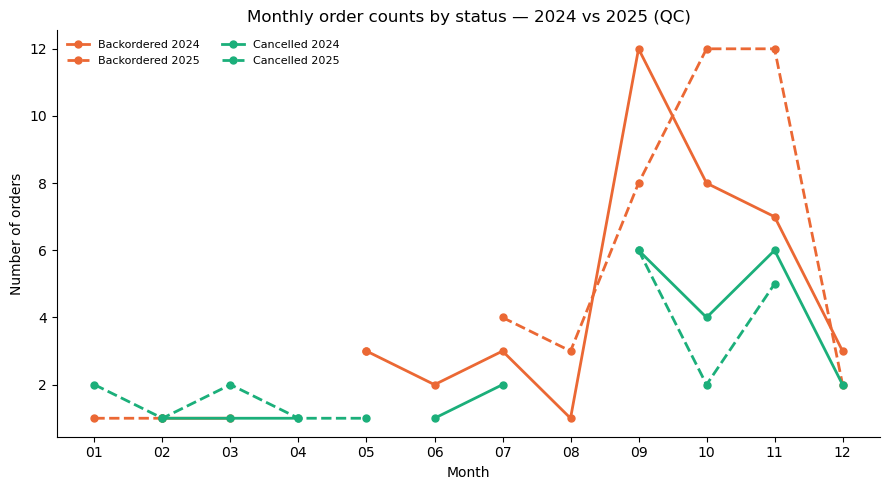

In [65]:
### count orders by status per month, 2024 vs 2025
import matplotlib.pyplot as plt

monthly= q("""
SELECT
  strftime('%Y', orders.order_date) AS year,
  strftime('%m', orders.order_date) AS month,
  orders.status,
  COUNT(*) AS n_orders
FROM orders
JOIN CUSTOMERS ON orders.customer_id = customers.customer_id 
WHERE strftime('%Y', orders.order_date) IN ('2024', '2025') 
AND orders.STATUS IN ('Backordered', 'Cancelled') 
AND customers.PROVINCE ='QC'
group by year, month, status
ORDER BY month, year, status
""")


month_order = [f'{m:02d}' for m in range(1, 13)]

status_colors = {
    'Backordered': '#eb6834',
    'Cancelled': '#1baf7a',
}
year_styles = {'2024': '-', '2025': '--'}

fig, ax = plt.subplots(figsize=(9, 5))
for status, color in status_colors.items():
    for year, style in year_styles.items():
        sub = (monthly[(monthly['status'] == status) & (monthly['year'] == year)]
               .set_index('month')
               .reindex(month_order)['n_orders'])
        ax.plot(month_order, sub.values, color=color, linestyle=style, linewidth=2,
                marker='o', markersize=5, label=f'{status} {year}')

ax.set_xlabel('Month')
ax.set_ylabel('Number of orders')
ax.set_title('Monthly order counts by status — 2024 vs 2025 (QC)')
ax.legend(ncol=2, fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()



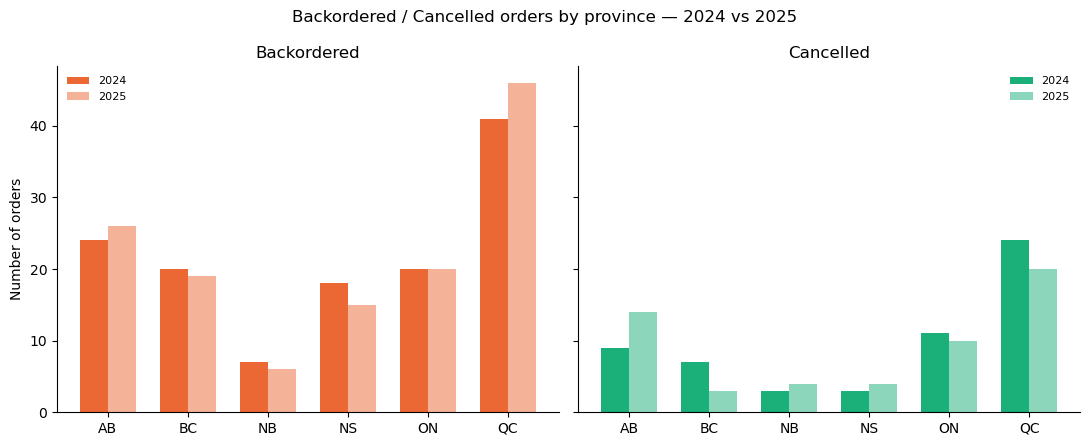

In [66]:
### total Backordered/Cancelled orders by province, 2024 vs 2025
import numpy as np

by_province = q("""
SELECT
  customers.province,
  strftime('%Y', orders.order_date) AS year,
  orders.status,
  COUNT(*) AS n_orders
FROM orders
JOIN customers ON orders.customer_id = customers.customer_id
WHERE strftime('%Y', orders.order_date) IN ('2024', '2025')
  AND orders.status IN ('Backordered', 'Cancelled')
GROUP BY province, year, status
ORDER BY province, year, status
""")

provinces = sorted(by_province['province'].unique())
x = np.arange(len(provinces))
width = 0.35

status_colors = {'Backordered': '#eb6834', 'Cancelled': '#1baf7a'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (status, color) in zip(axes, status_colors.items()):
    sub = by_province[by_province['status'] == status]
    counts_2024 = sub[sub['year'] == '2024'].set_index('province').reindex(provinces)['n_orders'].fillna(0)
    counts_2025 = sub[sub['year'] == '2025'].set_index('province').reindex(provinces)['n_orders'].fillna(0)

    ax.bar(x - width/2, counts_2024, width, color=color, alpha=1.0, label='2024')
    ax.bar(x + width/2, counts_2025, width, color=color, alpha=0.5, label='2025')

    ax.set_title(status)
    ax.set_xticks(x)
    ax.set_xticklabels(provinces)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel('Number of orders')
fig.suptitle('Backordered / Cancelled orders by province — 2024 vs 2025')
plt.tight_layout()
plt.show()

In [37]:
q("""
SELECT w.province, COUNT(*) AS n_orders
FROM orders o
JOIN warehouses w ON o.warehouse_id = w.warehouse_id
GROUP BY w.province
ORDER BY w.province
""")

,province,n_orders
0,AB,766
1,BC,762
2,NB,721
3,ON,705
4,QC,724


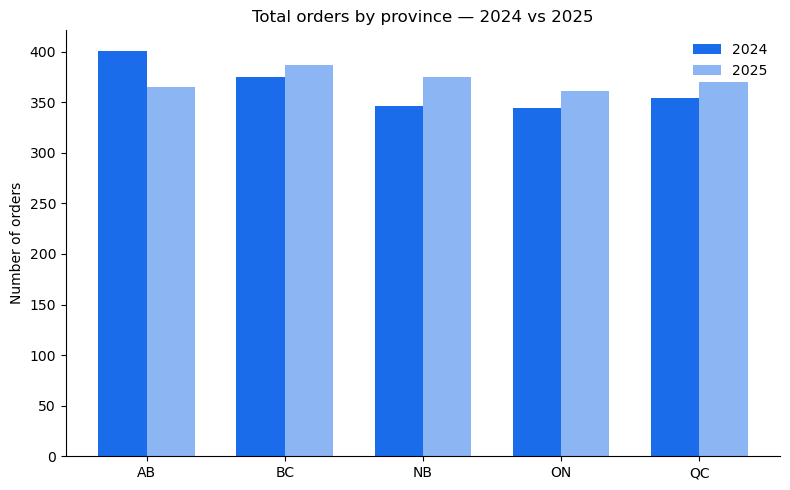

In [38]:
### total orders by province, 2024 vs 2025
import numpy as np
import matplotlib.pyplot as plt

orders_by_province = q("""
SELECT
  w.province,
  strftime('%Y', o.order_date) AS year,
  COUNT(*) AS n_orders
FROM orders o
JOIN warehouses w ON o.warehouse_id = w.warehouse_id
WHERE strftime('%Y', o.order_date) IN ('2024', '2025')
GROUP BY w.province, year
ORDER BY w.province, year
""")

provinces = sorted(orders_by_province['province'].unique())
x = np.arange(len(provinces))
width = 0.35

color = '#1b6ceb'
counts_2024 = (orders_by_province[orders_by_province['year'] == '2024']
               .set_index('province').reindex(provinces)['n_orders'].fillna(0))
counts_2025 = (orders_by_province[orders_by_province['year'] == '2025']
               .set_index('province').reindex(provinces)['n_orders'].fillna(0))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, counts_2024, width, color=color, alpha=1.0, label='2024')
ax.bar(x + width/2, counts_2025, width, color=color, alpha=0.5, label='2025')

ax.set_xticks(x)
ax.set_xticklabels(provinces)
ax.set_ylabel('Number of orders')
ax.set_title('Total orders by province — 2024 vs 2025')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [36]:
q("""
select o.order_id, o.customer_id, w.province, o.status, io.product_id, p.tire_type
from orders o
join order_items io on o.order_id = io.order_id
join products p on io.product_id = p.product_id
join warehouses w on o.warehouse_id = w.warehouse_id
where status in ('Backordered', 'Cancelled') 
and tire_type = 'Winter'
""")

,order_id,customer_id,province,status,product_id,tire_type
0,1,87,ON,Cancelled,49,Winter
1,16,75,ON,Backordered,26,Winter
2,124,131,NB,Backordered,42,Winter
3,129,16,BC,Backordered,10,Winter
4,151,3,BC,Backordered,58,Winter
...,...,...,...,...,...,...
191,3520,20,BC,Backordered,58,Winter
192,3628,131,NB,Backordered,57,Winter
193,3632,76,ON,Cancelled,50,Winter
194,3635,114,QC,Backordered,49,Winter


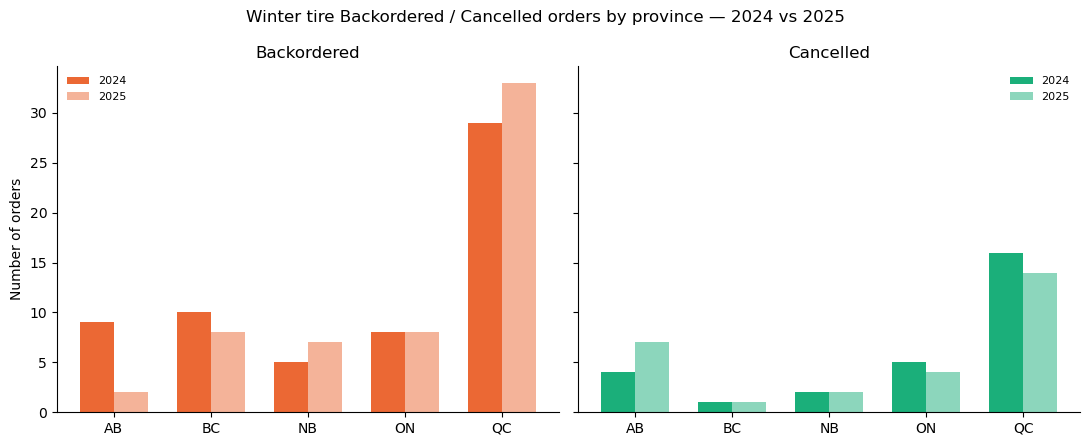

In [24]:

### Winter tire Backordered/Cancelled orders by province, 2024 vs 2025
import numpy as np
import matplotlib.pyplot as plt

winter_by_province = q("""
SELECT
  w.province,
  strftime('%Y', o.order_date) AS year,
  o.status,
  COUNT(DISTINCT o.order_id) AS n_orders
FROM orders o
JOIN order_items io ON o.order_id = io.order_id
JOIN products p ON io.product_id = p.product_id
JOIN warehouses w ON o.warehouse_id = w.warehouse_id
WHERE o.status IN ('Backordered', 'Cancelled')
  AND p.tire_type = 'Winter'
  AND strftime('%Y', o.order_date) IN ('2024', '2025')
GROUP BY w.province, year, o.status
ORDER BY w.province, year, o.status
""")

provinces = sorted(winter_by_province['province'].unique())
x = np.arange(len(provinces))
width = 0.35

status_colors = {'Backordered': '#eb6834', 'Cancelled': '#1baf7a'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (status, color) in zip(axes, status_colors.items()):
    sub = winter_by_province[winter_by_province['status'] == status]
    counts_2024 = sub[sub['year'] == '2024'].set_index('province').reindex(provinces)['n_orders'].fillna(0)
    counts_2025 = sub[sub['year'] == '2025'].set_index('province').reindex(provinces)['n_orders'].fillna(0)

    ax.bar(x - width/2, counts_2024, width, color=color, alpha=1.0, label='2024')
    ax.bar(x + width/2, counts_2025, width, color=color, alpha=0.5, label='2025')

    ax.set_title(status)
    ax.set_xticks(x)
    ax.set_xticklabels(provinces)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel('Number of orders')
fig.suptitle('Winter tire Backordered / Cancelled orders by province — 2024 vs 2025')
plt.tight_layout()
plt.show()

In [ ]:
### Ordered/Cancelled orders shipped from a warehouse in a different province than the customer
q("""
SELECT orders.customer_id,customers.province, orders.warehouse_id,warehouses.province as warehouse_province
from orders
join customers on orders.customer_id = customers.customer_id
join warehouses on orders.warehouse_id = warehouses.warehouse_id
where warehouses.province != customers.province and orders.status in ('Backordered', 'Cancelled')
""")

,customer_id,province,warehouse_id,warehouse_province
0,156,NS,5,NB
1,131,NS,5,NB
2,157,NS,5,NB
3,132,NS,5,NB
4,155,NS,5,NB
5,134,NS,5,NB
6,146,NS,5,NB
7,146,NS,5,NB
8,146,NS,5,NB
9,143,NS,5,NB


In [45]:
q("""
SELECT status, COUNT(*) AS n_orders
from orders 
group by status limit 5
""")

,status,n_orders
0,Backordered,262
1,Cancelled,112
2,Fulfilled,3304


In [5]:
q("""
SELECT
  w.province,
  SUM(CASE WHEN status = 'Backordered' THEN 1 ELSE 0 END) AS n_backordered,
  COUNT(*) AS n_total,
  1.0 * SUM(CASE WHEN status = 'Backordered' THEN 1 ELSE 0 END) / COUNT(*) AS backorder_rate
FROM orders
JOIN warehouses w ON orders.warehouse_id = w.warehouse_id
JOIN ORDER_ITEMS io ON orders.order_id = io.order_id
JOIN PRODUCTS p ON io.product_id = p.product_id
WHERE p.tire_type = 'Winter'
GROUP BY w.province
ORDER BY w.province
""")


,province,n_backordered,n_total,backorder_rate
0,AB,11,255,0.043137
1,BC,22,272,0.080882
2,NB,13,228,0.057018
3,ON,16,258,0.062016
4,QC,70,242,0.289256


In [18]:
q(""" 
  select w.province,ins.snapshot_date,sum(ins.quantity_on_hand) as total_quantity, p.tire_type
    from inventory_snapshots ins
    join products p on ins.product_id = p.product_id
    join warehouses w on ins.warehouse_id = w.warehouse_id
    where p.tire_type = 'Winter' and province = 'QC'
    group by p.tire_type , w.province, ins.snapshot_date
""")

,province,snapshot_date,total_quantity,tire_type
0,QC,2024-01-01,1740,Winter
1,QC,2024-01-08,1730,Winter
2,QC,2024-01-15,1735,Winter
3,QC,2024-01-22,1630,Winter
4,QC,2024-01-29,1526,Winter
...,...,...,...,...
100,QC,2025-12-01,1469,Winter
101,QC,2025-12-08,1548,Winter
102,QC,2025-12-15,1657,Winter
103,QC,2025-12-22,1627,Winter


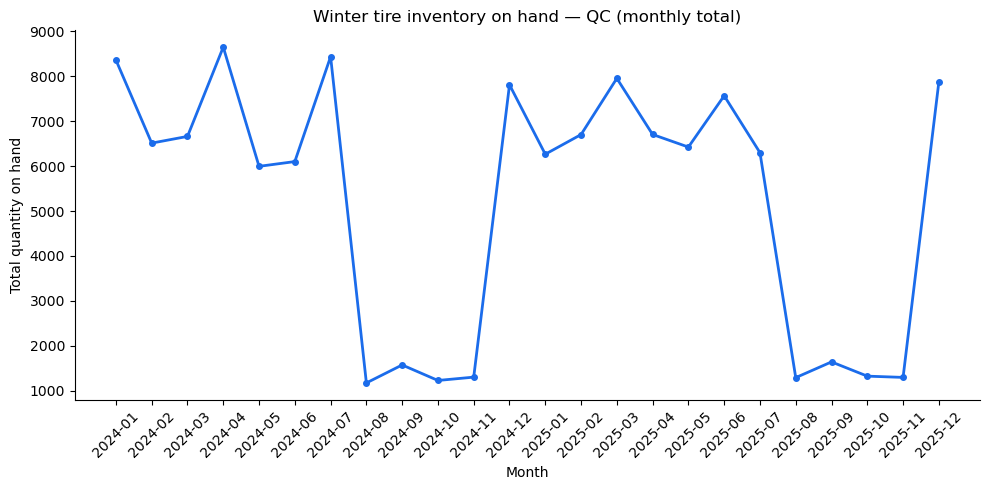

In [27]:
df = q("""
SELECT
  strftime('%Y-%m', ins.snapshot_date) AS month,
  sum(ins.quantity_on_hand) AS total_quantity
FROM inventory_snapshots ins
JOIN products p ON ins.product_id = p.product_id
JOIN warehouses w ON ins.warehouse_id = w.warehouse_id
WHERE p.tire_type = 'Winter' AND w.province = 'QC'
GROUP BY month
ORDER BY month
""")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['month'], df['total_quantity'], color='#1b6ceb', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Month')
ax.set_ylabel('Total quantity on hand')
ax.set_title('Winter tire inventory on hand — QC (monthly total)')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


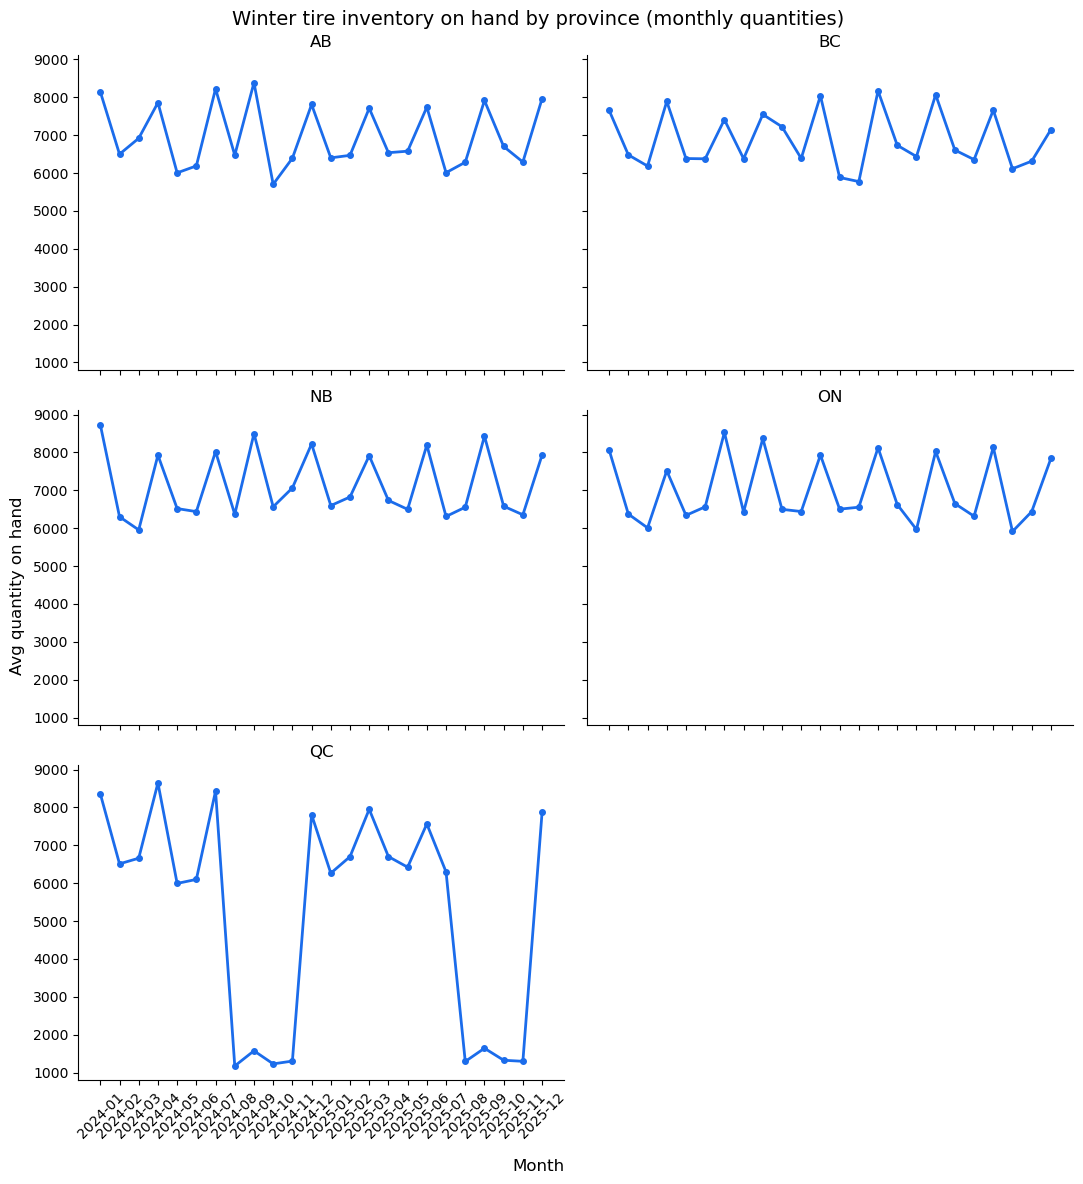

In [ ]:
df = q("""
SELECT
  w.province,
  strftime('%Y-%m', ins.snapshot_date) AS month,
  sum(ins.quantity_on_hand) AS sum_quantity
FROM inventory_snapshots ins
JOIN products p ON ins.product_id = p.product_id
JOIN warehouses w ON ins.warehouse_id = w.warehouse_id
WHERE p.tire_type = 'Winter'
GROUP BY w.province, month
ORDER BY w.province, month
""")

provinces = sorted(df['province'].unique())
ncols = 2
nrows = -(-len(provinces) // ncols)  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(11, 4 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

for ax, province in zip(axes, provinces):
    sub = df[df['province'] == province]
    ax.plot(sub['month'], sub['sum_quantity'], color="#1b6ceb", linewidth=2, marker='o', markersize=4)
    ax.set_title(province)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(provinces):]:
    ax.set_visible(False)

fig.suptitle('Winter tire inventory on hand by province (monthly quantities)', fontsize=14)
fig.supxlabel('Month')
fig.supylabel('Avg quantity on hand')
plt.tight_layout()
plt.show()

In [27]:
q("""
SELECT strftime('%Y-%m',o.order_date) as date, o.warehouse_id, oi.unit_price, o.status, oi.quantity_ordered, oi.quantity_fulfilled
, (oi.unit_price * (oi.quantity_ordered - oi.quantity_fulfilled)) as total_order_lost
FROM 
order_items as oi
JOIN orders as o ON oi.order_id = o.order_id
where quantity_fulfilled < quantity_ordered 
and o.warehouse_id = 4
""")

,date,warehouse_id,unit_price,status,quantity_ordered,quantity_fulfilled,total_order_lost
0,2024-02,4,195.52,Cancelled,4,0,782.08
1,2024-02,4,119.71,Backordered,16,0,1915.36
2,2024-03,4,188.34,Cancelled,8,0,1506.72
3,2024-03,4,92.71,Backordered,16,0,1483.36
4,2024-04,4,115.69,Cancelled,4,0,462.76
...,...,...,...,...,...,...,...
153,2025-11,4,217.71,Backordered,8,0,1741.68
154,2025-11,4,190.02,Backordered,8,0,1520.16
155,2025-12,4,146.57,Backordered,20,0,2931.40
156,2025-12,4,153.08,Backordered,4,2,306.16


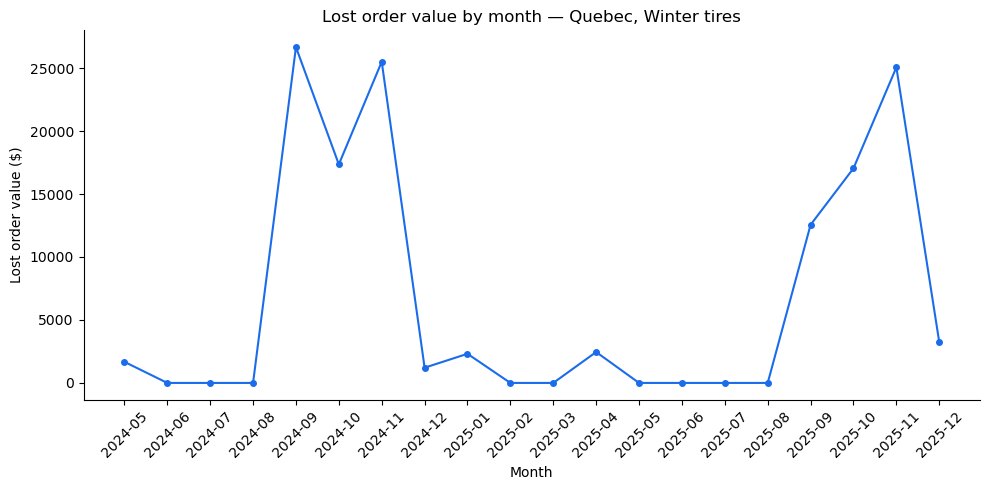

In [36]:
df = q("""
SELECT
  strftime('%Y-%m', o.order_date) AS month,
  SUM(oi.unit_price * (oi.quantity_ordered - oi.quantity_fulfilled)) AS total_order_lost,
  p.tire_type
FROM order_items AS oi
JOIN orders AS o ON oi.order_id = o.order_id
JOIN products AS p ON oi.product_id = p.product_id
WHERE oi.quantity_fulfilled < oi.quantity_ordered
  AND o.warehouse_id = 4
  and p.tire_type = 'Winter'
GROUP BY month
ORDER BY month
""")

all_months = pd.date_range(df['month'].min(), df['month'].max(), freq='MS').strftime('%Y-%m')
s = df.set_index('month')['total_order_lost'].reindex(all_months).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(s.index, s.values, color='#1b6ceb', marker='o', markersize=4)
ax.set_xlabel('Month')
ax.set_ylabel('Lost order value ($)')
ax.set_title('Lost order value by month — Quebec, Winter tires')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
q("""
SELECT
    SUM((oi.quantity_ordered - oi.quantity_fulfilled) * oi.unit_price) AS at_risk_revenue,
    SUM(oi.quantity_ordered - oi.quantity_fulfilled) AS units_short,
    COUNT(DISTINCT o.order_id) AS affected_orders
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN warehouses w ON o.warehouse_id = w.warehouse_id
WHERE w.province = 'QC' 
  AND p.tire_type = 'Winter'
  AND strftime('%m', o.order_date) IN ('09','10','11')
  AND oi.quantity_fulfilled < oi.quantity_ordered
""")

,at_risk_revenue,units_short,affected_orders
0,124168.8,738,87
